# Questão 3

O PDF cita um `script` externo chamado `non_stationary_signal.ipynb`, mas esse arquivo não está presente no repositório local.
Para manter a prática executável sem downloads, foi montado abaixo um sinal não estacionário equivalente, com trechos senoidais,
um chirp, uma rajada modulada e um transiente impulsivo.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.io import loadmat, wavfile
from scipy.linalg import hadamard
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'pratica_5' / 'Aula_Prática_5.pdf').exists():
    REPO_ROOT = CWD
    PRACTICE_DIR = CWD / 'pratica_5'
elif (CWD / 'Aula_Prática_5.pdf').exists():
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent
else:
    PRACTICE_DIR = CWD
    REPO_ROOT = CWD.parent

DATA_DIR = REPO_ROOT / 'data'

def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def plot_spectrum(ax, signal_in, fs, title, xlim=None):
    freqs = np.fft.rfftfreq(len(signal_in), d=1 / fs)
    mag = np.abs(np.fft.rfft(signal_in))
    ax.plot(freqs, mag)
    ax.set_title(title)
    ax.set_xlabel('Frequencia (Hz)')
    ax.set_ylabel('Magnitude')
    if xlim is not None:
        ax.set_xlim(*xlim)
    ax.grid(True, alpha=0.3)


def coeffs_table(wavelet_name):
    w = pywt.Wavelet(wavelet_name)
    return [
        {'Filtro': 'dec_lo', 'Coeficientes': np.array2string(np.array(w.dec_lo), precision=8, separator=', ')},
        {'Filtro': 'dec_hi', 'Coeficientes': np.array2string(np.array(w.dec_hi), precision=8, separator=', ')},
        {'Filtro': 'rec_lo', 'Coeficientes': np.array2string(np.array(w.rec_lo), precision=8, separator=', ')},
        {'Filtro': 'rec_hi', 'Coeficientes': np.array2string(np.array(w.rec_hi), precision=8, separator=', ')},
    ]


def plot_wavelet_decomposition(signal_in, coeffs, title):
    levels = len(coeffs) - 1
    fig, axes = plt.subplots(levels + 2, 1, figsize=(12, 2.3 * (levels + 2)))
    axes[0].plot(signal_in)
    axes[0].set_title(f'{title} - sinal original')
    axes[0].set_xlabel('Amostra normalizada')
    axes[0].set_ylabel('Amplitude')

    axes[1].plot(coeffs[0])
    axes[1].set_title(f'{title} - aproximacao A{levels}')
    axes[1].set_xlabel('Indice do coeficiente')
    axes[1].set_ylabel('Coef.')

    for idx, detail in enumerate(coeffs[1:], start=1):
        level = levels - idx + 1
        axes[idx + 1].plot(detail)
        axes[idx + 1].set_title(f'{title} - detalhe D{level}')
        axes[idx + 1].set_xlabel('Indice do coeficiente')
        axes[idx + 1].set_ylabel('Coef.')

    plt.tight_layout()
    plt.show()


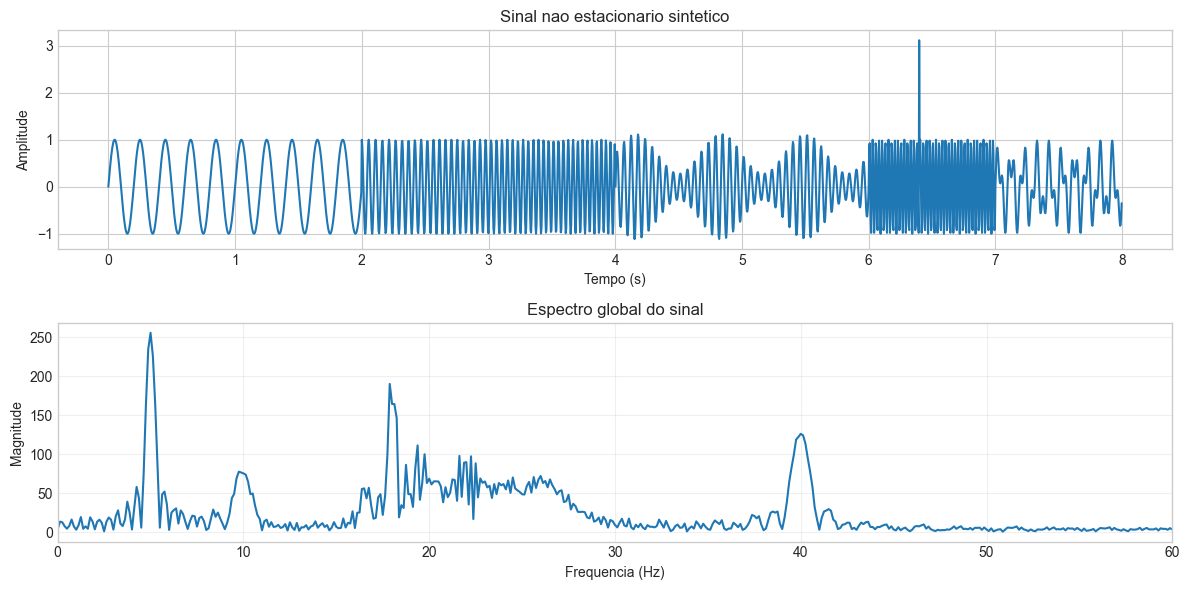

In [2]:
fs = 256
N = 2048
t = np.arange(N) / fs
x = np.zeros_like(t)

seg1 = t < 2
seg2 = (t >= 2) & (t < 4)
seg3 = (t >= 4) & (t < 6)
seg4 = (t >= 6) & (t < 7)
seg5 = t >= 7

x[seg1] = np.sin(2 * np.pi * 5 * t[seg1])
x[seg2] = signal.chirp(t[seg2], f0=8, f1=28, t1=t[seg2][-1], method='linear')
x[seg3] = 0.7 * np.sin(2 * np.pi * 18 * t[seg3]) * (1 + 0.6 * np.sin(2 * np.pi * 1.5 * t[seg3]))
x[seg4] = np.sin(2 * np.pi * 40 * t[seg4])
x[int(6.4 * fs)] += 3.5
x[seg5] = 0.6 * np.sin(2 * np.pi * 10 * t[seg5]) + 0.4 * np.sin(2 * np.pi * 22 * t[seg5])

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t, x)
axes[0].set_title('Sinal nao estacionario sintetico')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Amplitude')
plot_spectrum(axes[1], x, fs=fs, title='Espectro global do sinal', xlim=(0, 60))
plt.tight_layout()
plt.show()


Filtros da wavelet bior4.4:
Filtro | Coeficientes                                                                                                                       
-------+------------------------------------------------------------------------------------------------------------------------------------
dec_lo | [ 0.        ,  0.03782846, -0.02384947, -0.1106244 ,  0.37740286,
  0.85269868,  0.37740286, -0.1106244 , -0.02384947,  0.03782846]
dec_hi | [-0.        , -0.06453888,  0.04068942,  0.41809227, -0.78848562,
  0.41809227,  0.04068942, -0.06453888, -0.        ,  0.        ]
rec_lo | [ 0.        , -0.06453888, -0.04068942,  0.41809227,  0.78848562,
  0.41809227, -0.04068942, -0.06453888,  0.        ,  0.        ]
rec_hi | [ 0.        , -0.03782846, -0.02384947,  0.1106244 ,  0.37740286,
 -0.85269868,  0.37740286,  0.1106244 , -0.02384947, -0.03782846]


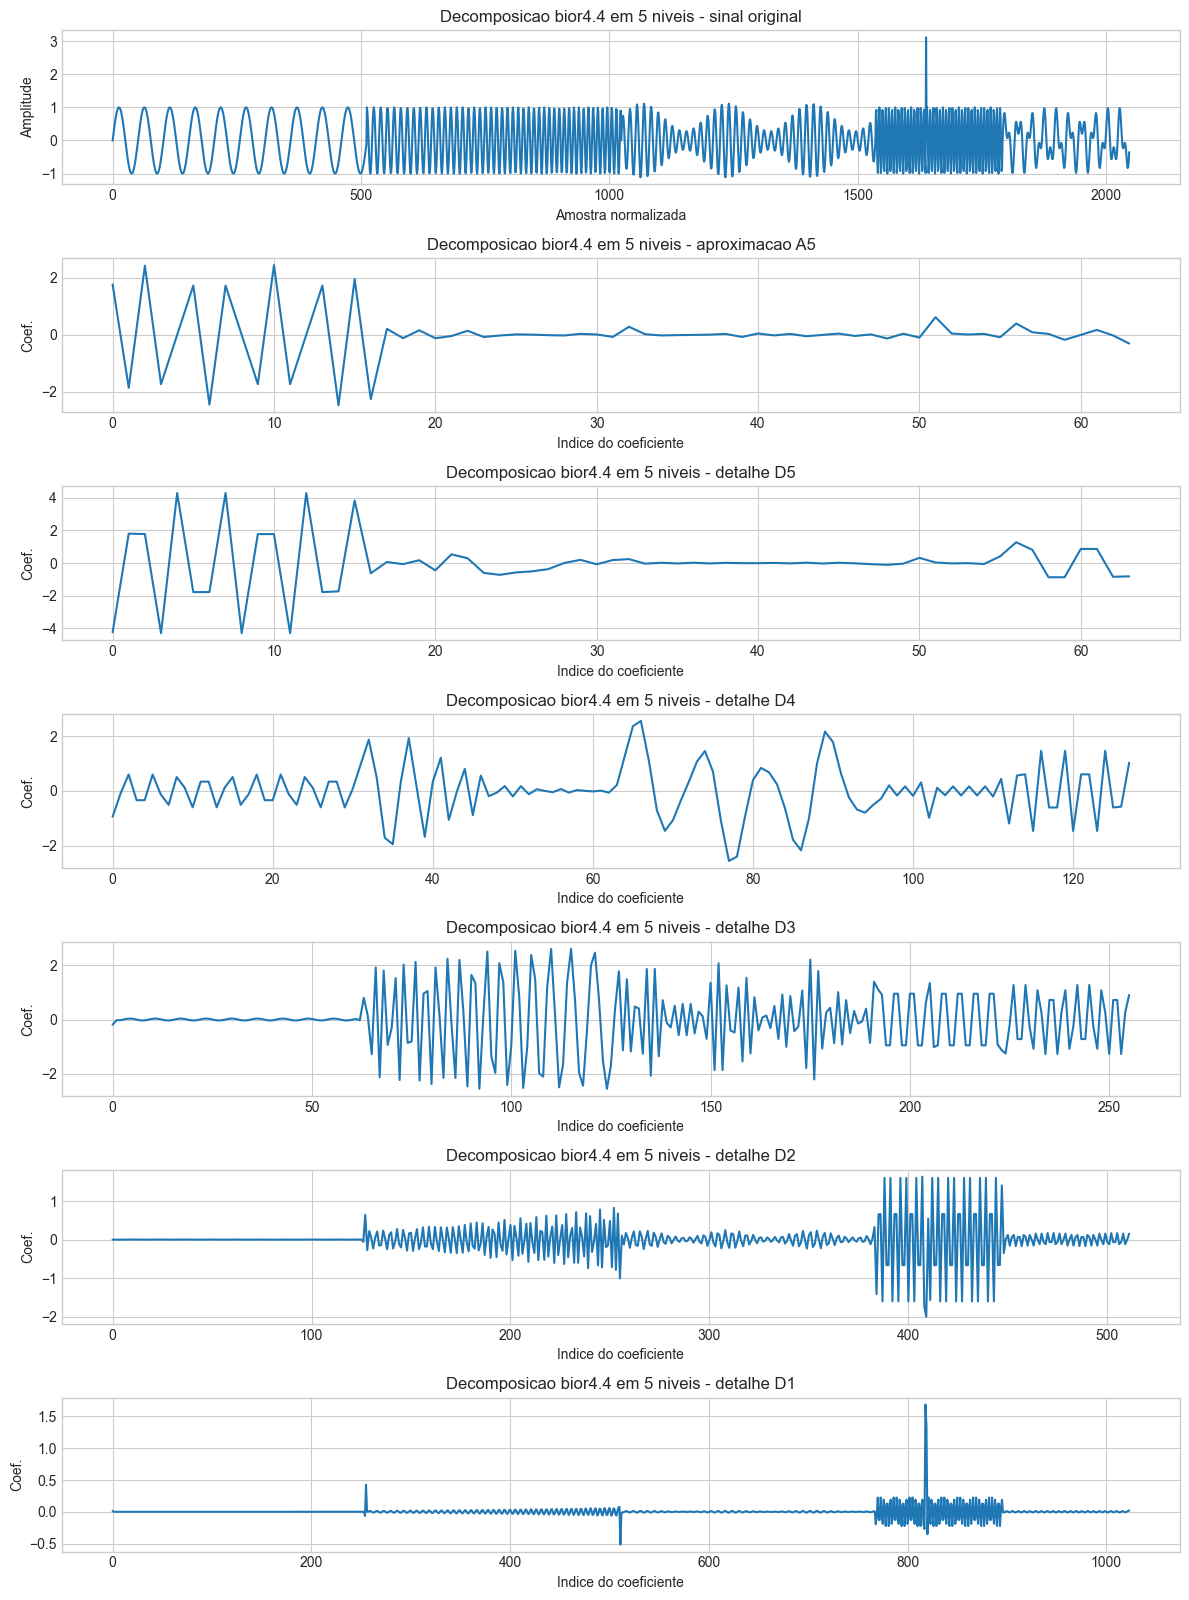

In [3]:
print('Filtros da wavelet bior4.4:')
display_rows(coeffs_table('bior4.4'))

coeffs = pywt.wavedec(x, 'bior4.4', level=5, mode='periodization')
plot_wavelet_decomposition(x, coeffs, 'Decomposicao bior4.4 em 5 niveis')


In [4]:
rows = []
for idx, c in enumerate(coeffs):
    if idx == 0:
        rows.append({'Subfaixa': 'A5', 'Comprimento': len(c), 'Energia': float(np.sum(c ** 2))})
    else:
        level = 6 - idx
        rows.append({'Subfaixa': f'D{level}', 'Comprimento': len(c), 'Energia': float(np.sum(c ** 2))})

display_rows(rows, float_digits=8)


Subfaixa | Comprimento | Energia     
---------+-------------+-------------
A5       | 64          | 58.41224460 
D5       | 64          | 178.55560664
D4       | 128         | 107.92815630
D3       | 256         | 333.33164445
D2       | 512         | 121.77662123
D1       | 1024        | 8.74105148  


## Comentários

- A decomposição multiescala separa adequadamente os trechos lentos, os componentes oscilatórios e o transiente impulsivo.
- As subfaixas de detalhe de níveis mais baixos concentram eventos mais rápidos e variações bruscas.
- A aproximação `A5` resume a estrutura mais lenta do sinal ao longo do tempo.
